In [16]:
# ============================================================
# NIHL Gene Expression Analysis Pipeline
# Dataset: GSE100365
# Purpose: Differential expression + annotation + PCA
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import gzip
import urllib.request
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [69]:
file_path = r"C:\Users\dhrub\Downloads\GSE100365_series_matrix.txt"

data = pd.read_csv(
    file_path,
    sep="\t",
    comment="!",
    low_memory=False
)

# Clean column names
data.columns = data.columns.str.strip()

print(data.head())
print("Original shape:", data.shape)

         ID_REF  GSM2679575  GSM2679576  GSM2679577  GSM2679578  GSM2679579  \
0    1415670_at        9.23        9.08        9.16        9.24        9.25   
1    1415671_at       10.68       10.72       10.80       10.88       10.79   
2    1415672_at       10.96       10.93       10.80       10.90       10.91   
3    1415673_at        7.34        7.38        7.34        7.42        7.15   
4  1415674_a_at        9.24        9.17        9.21        9.33        9.20   

   GSM2679580  GSM2679581  GSM2679582  GSM2679583  GSM2679584  GSM2679585  \
0        9.14        9.31        9.30        9.35        9.27        9.26   
1       10.77       10.82       10.83       10.77       10.84       10.91   
2       10.80       10.97       10.89       10.89       10.90       10.80   
3        7.30        7.55        7.62        7.56        7.21        7.38   
4        9.14        9.24        9.22        9.20        9.27        9.27   

   GSM2679586  GSM2679587  GSM2679588  GSM2679589  
0        9

In [18]:
# ----------------------------
# Restructure data
# Rows should be samples, columns should be genes/probes
# ----------------------------

data = data.set_index("ID_REF")

data_t = data.T

print(data_t.head())
print("Shape after transpose:", data_t.shape)

ID_REF      1415670_at  1415671_at  1415672_at  1415673_at  1415674_a_at  \
GSM2679575        9.23       10.68       10.96        7.34          9.24   
GSM2679576        9.08       10.72       10.93        7.38          9.17   
GSM2679577        9.16       10.80       10.80        7.34          9.21   
GSM2679578        9.24       10.88       10.90        7.42          9.33   
GSM2679579        9.25       10.79       10.91        7.15          9.20   

ID_REF      1415675_at  1415676_a_at  1415677_at  1415678_at  1415679_at  ...  \
GSM2679575        8.64         10.28        9.47       10.58       10.51  ...   
GSM2679576        8.57         10.34        9.48       10.66       10.62  ...   
GSM2679577        8.54         10.38        9.41       10.55       10.53  ...   
GSM2679578        8.53         10.19        9.51       10.50       10.53  ...   
GSM2679579        8.37         10.30        9.57       10.53       10.49  ...   

ID_REF      AFFX-r2-P1-cre-5_at  AFFX-ThrX-3_at  AFFX-Th

In [19]:
# ----------------------------
# Extract sample group labels from metadata
# ----------------------------

groups = []

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            parts = line.strip().split("\t")
            groups = parts[1:]  # skip metadata label
            break

print("Sample group names:")
print(groups)

print("Number of sample labels:", len(groups))
print("Number of rows in data_t:", data_t.shape[0])

Sample group names:
['"AuditoryNerve_control_rep1"', '"AuditoryNerve_control_rep2"', '"AuditoryNerve_control_rep3"', '"AuditoryNerve_Noise_Immediate_rep1"', '"AuditoryNerve_Noise_Immediate_rep2"', '"AuditoryNerve_Noise_Immediate_rep3"', '"AuditoryNerve_Noise_1Day_rep1"', '"AuditoryNerve_Noise_1Day_rep2"', '"AuditoryNerve_Noise_1Day_rep3"', '"AuditoryNerve_Noise_7Day_rep1"', '"AuditoryNerve_Noise_7Day_rep2"', '"AuditoryNerve_Noise_7Day_rep3"', '"AuditoryNerve_Noise_14Day_rep1"', '"AuditoryNerve_Noise_14Day_rep2"', '"AuditoryNerve_Noise_14Day_rep3"']
Number of sample labels: 15
Number of rows in data_t: 15


In [20]:
# ----------------------------
# Convert sample titles to binary group labels
# ----------------------------

labels = [0 if "control" in g.lower() else 1 for g in groups]

data_t["group"] = labels

print(data_t["group"].value_counts())
print(data_t.head())

group
1    12
0     3
Name: count, dtype: int64
ID_REF      1415670_at  1415671_at  1415672_at  1415673_at  1415674_a_at  \
GSM2679575        9.23       10.68       10.96        7.34          9.24   
GSM2679576        9.08       10.72       10.93        7.38          9.17   
GSM2679577        9.16       10.80       10.80        7.34          9.21   
GSM2679578        9.24       10.88       10.90        7.42          9.33   
GSM2679579        9.25       10.79       10.91        7.15          9.20   

ID_REF      1415675_at  1415676_a_at  1415677_at  1415678_at  1415679_at  ...  \
GSM2679575        8.64         10.28        9.47       10.58       10.51  ...   
GSM2679576        8.57         10.34        9.48       10.66       10.62  ...   
GSM2679577        8.54         10.38        9.41       10.55       10.53  ...   
GSM2679578        8.53         10.19        9.51       10.50       10.53  ...   
GSM2679579        8.37         10.30        9.57       10.53       10.49  ...   

ID_REF  

In [21]:
# ----------------------------
# Convert expression values to numeric
# ----------------------------

gene_columns = data_t.columns.drop("group")

data_t[gene_columns] = data_t[gene_columns].apply(pd.to_numeric, errors="coerce")

print("Missing values:", data_t[gene_columns].isnull().sum().sum())
print(data_t.dtypes.head())

Missing values: 0
ID_REF
1415670_at      float64
1415671_at      float64
1415672_at      float64
1415673_at      float64
1415674_a_at    float64
dtype: object


In [23]:
# ----------------------------
# Differential expression analysis
# Welch's t-test: control vs noise
# ----------------------------

control = data_t[data_t["group"] == 0].drop(columns=["group"])
noise = data_t[data_t["group"] == 1].drop(columns=["group"])

results = []

for gene in control.columns:
    stat, pval = ttest_ind(control[gene], noise[gene], equal_var=False)
    results.append([gene, stat, pval])

results_df = pd.DataFrame(results, columns=["Gene", "T-stat", "P-value"])

results_df = results_df.sort_values("P-value")

print(results_df.head(10))

C:\Users\dhrub\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


               Gene     T-stat       P-value
7355   1423050_s_at -10.696219  2.535651e-07
32855    1448556_at  -9.925903  4.287489e-07
36932  1452638_s_at  -8.587807  1.050781e-06
39224    1454930_at   8.597061  1.085801e-06
40455    1456161_at   9.183157  1.299282e-06
7071     1422766_at  -8.015803  2.275546e-06
30185    1445880_at  -8.207897  2.936741e-06
37127    1452833_at  -7.868483  2.988238e-06
29271    1444966_at   7.670699  3.792920e-06
14894    1430589_at  -7.626388  3.808678e-06


In [24]:
# ----------------------------
# Add group means and log2 fold-change
# ----------------------------

results_df["Control_Mean"] = results_df["Gene"].apply(lambda g: control[g].mean())
results_df["Noise_Mean"] = results_df["Gene"].apply(lambda g: noise[g].mean())

# Since microarray values are already log2-like, difference approximates log2FC
results_df["Log2FC"] = results_df["Noise_Mean"] - results_df["Control_Mean"]

# Clean possible invalid values
results_df = results_df.replace([np.inf, -np.inf], np.nan).dropna()

results_df["Abs_Log2FC"] = results_df["Log2FC"].abs()

results_df = results_df.sort_values(["P-value", "Abs_Log2FC"], ascending=[True, False])

print(results_df.head(20))

               Gene     T-stat       P-value  Control_Mean  Noise_Mean  \
7355   1423050_s_at -10.696219  2.535651e-07     10.433333   10.700833   
32855    1448556_at  -9.925903  4.287489e-07      2.696667    3.020000   
36932  1452638_s_at  -8.587807  1.050781e-06      7.266667    7.611667   
39224    1454930_at   8.597061  1.085801e-06      8.810000    8.520000   
40455    1456161_at   9.183157  1.299282e-06      5.120000    4.606667   
7071     1422766_at  -8.015803  2.275546e-06      8.303333    8.502500   
30185    1445880_at  -8.207897  2.936741e-06      5.263333    5.639167   
37127    1452833_at  -7.868483  2.988238e-06     10.150000   10.289167   
29271    1444966_at   7.670699  3.792920e-06      6.593333    6.383333   
14894    1430589_at  -7.626388  3.808678e-06      3.150000    3.470000   
24030    1439725_at   7.718444  3.982603e-06      6.776667    6.577500   
11421    1427116_at   7.622342  4.242828e-06      7.793333    7.635833   
13297    1428992_at  -7.798699  4.6610

In [25]:
# ----------------------------
# Load GPL1261 annotation file
# ----------------------------

annotation_url = "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPL1nnn/GPL1261/annot/GPL1261.annot.gz"

with urllib.request.urlopen(annotation_url) as response:
    with gzip.open(response, "rt", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

# Find where the annotation table starts
for i, line in enumerate(lines):
    if line.startswith("ID\t"):
        start = i
        print("Annotation table starts at line:", start)
        break

annot = pd.read_csv(
    annotation_url,
    sep="\t",
    compression="gzip",
    skiprows=start,
    low_memory=False
)

annot.columns = annot.columns.str.strip()

print(annot.head())
print("Annotation shape:", annot.shape)
print(annot.columns)

Annotation table starts at line: 27
             ID                                        Gene title Gene symbol  \
0    1415670_at         coatomer protein complex, subunit gamma 1       Copg1   
1    1415671_at  ATPase, H+ transporting, lysosomal V0 subunit D1    Atp6v0d1   
2    1415672_at          golgi autoantigen, golgin subfamily a, 7      Golga7   
3    1415673_at                         phosphoserine phosphatase        Psph   
4  1415674_a_at            trafficking protein particle complex 4     Trappc4   

  Gene ID UniGene title UniGene symbol UniGene ID  \
0   54161           NaN            NaN        NaN   
1   11972           NaN            NaN        NaN   
2   57437           NaN            NaN        NaN   
3  100678           NaN            NaN        NaN   
4   60409           NaN            NaN        NaN   

                                    Nucleotide Title           GI  \
0  Mus musculus coatomer protein complex, subunit...   19354080.0   
1  Mus musculus ATPa

In [26]:
# ----------------------------
# Merge probe-level DEG results with gene annotation
# ----------------------------

merged = results_df.merge(
    annot,
    left_on="Gene",
    right_on="ID",
    how="left"
)

print(merged.head())
print(merged.columns)

           Gene     T-stat       P-value  Control_Mean  Noise_Mean    Log2FC  \
0  1423050_s_at -10.696219  2.535651e-07     10.433333   10.700833  0.267500   
1    1448556_at  -9.925903  4.287489e-07      2.696667    3.020000  0.323333   
2  1452638_s_at  -8.587807  1.050781e-06      7.266667    7.611667  0.345000   
3    1454930_at   8.597061  1.085801e-06      8.810000    8.520000 -0.290000   
4    1456161_at   9.183157  1.299282e-06      5.120000    4.606667 -0.513333   

   Abs_Log2FC            ID                                 Gene title  \
0    0.267500  1423050_s_at  heterogeneous nuclear ribonucleoprotein U   
1    0.323333    1448556_at                         prolactin receptor   
2    0.345000  1452638_s_at                             dynamin 1-like   
3    0.290000    1454930_at            tubulin folding cofactor E-like   
4    0.513333    1456161_at                 RIKEN cDNA 0610040B10 gene   

     Gene symbol  ... Platform_ORF Platform_SPOTID Chromosome location  \


In [27]:
# ----------------------------
# Create clean final results table
# ----------------------------

final_results = merged[[
    "Gene", "Gene symbol", "Gene title",
    "T-stat", "P-value", "Control_Mean", "Noise_Mean", "Log2FC", "Abs_Log2FC",
    "GO:Function", "GO:Process", "GO:Component"
]].copy()

final_results = final_results.rename(columns={
    "Gene": "Probe_ID",
    "Gene symbol": "Gene_Symbol",
    "Gene title": "Gene_Title"
})

final_results = final_results.sort_values("P-value")

print(final_results.head(20))

        Probe_ID           Gene_Symbol  \
0   1423050_s_at                Hnrnpu   
1     1448556_at                  Prlr   
2   1452638_s_at                 Dnm1l   
3     1454930_at                 Tbcel   
4     1456161_at         0610040B10Rik   
5     1422766_at                 Stau1   
6     1445880_at                   NaN   
7     1452833_at               Rapgef2   
8     1444966_at                   NaN   
9     1430589_at                  Pigh   
10    1439725_at                 Ptprt   
11    1427116_at                Setd1a   
12    1428992_at                Unc13d   
13    1417183_at                Dnaja2   
14    1453290_at                Hmgxb4   
15    1434275_at                  Nkd2   
16    1440084_at                   NaN   
17    1428436_at                Lsm14a   
18  1417339_a_at                Dynll1   
19    1430982_at  LOC102641923///Srsf1   

                                           Gene_Title     T-stat  \
0           heterogeneous nuclear ribonucleoprote

In [28]:
# ----------------------------
# Search for oxidative stress / Nrf2-related genes
# ----------------------------

target_genes = [
    "Nfe2l2", "Sod1", "Sod2", "Gpx1", "Cat", "Sirt1",
    "Hmox1", "Nqo1", "Gclc", "Gclm", "Txnrd1",
    "Dnm1l", "Dnaja2"
]

target_results = final_results[
    final_results["Gene_Symbol"].astype(str).str.contains(
        "|".join(target_genes),
        case=False,
        na=False
    )
]

target_results = target_results.sort_values("P-value")

print(target_results[[
    "Probe_ID", "Gene_Symbol", "Gene_Title", "P-value", "Log2FC"
]])

           Probe_ID Gene_Symbol  \
2      1452638_s_at       Dnm1l   
13       1417183_at      Dnaja2   
70     1429476_s_at      Dnaja2   
343      1428087_at       Dnm1l   
1051     1417182_at      Dnaja2   
...             ...         ...   
42756  1421529_a_at      Txnrd1   
42780  1416429_a_at         Cat   
43920    1425309_at    Catsper2   
44120    1424182_at       Acat1   
44762    1440684_at      Lpcat2   

                                             Gene_Title   P-value    Log2FC  
2                                        dynamin 1-like  0.000001  0.345000  
13     DnaJ heat shock protein family (Hsp40) member A2  0.000006  0.158333  
70     DnaJ heat shock protein family (Hsp40) member A2  0.000066  0.099167  
343                                      dynamin 1-like  0.000867  0.105000  
1051   DnaJ heat shock protein family (Hsp40) member A2  0.006106 -0.067500  
...                                                 ...       ...       ...  
42756                           t

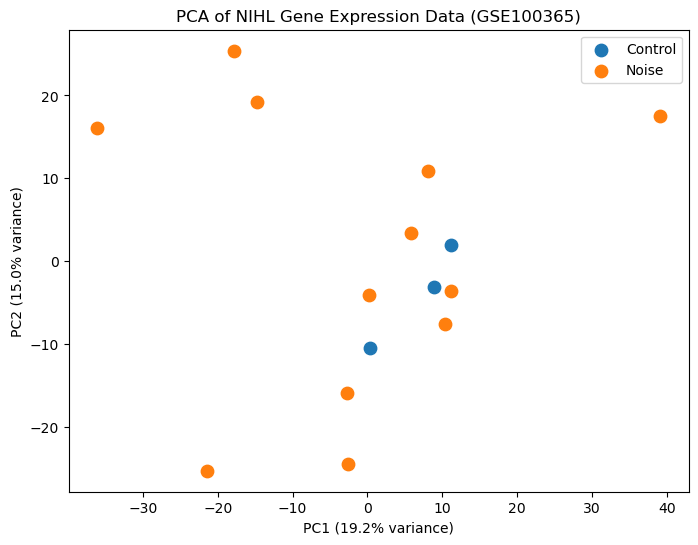

Explained variance by PC1 and PC2:
[0.19207482 0.14957894]


In [30]:
# ----------------------------
# Principal Component Analysis
# ----------------------------

# Features only
X = data_t.drop(columns=["group"])

# Convert all values to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove probes with missing values, if any
X = X.dropna(axis=1)

# PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))

for label, name in zip([0, 1], ["Control", "Noise"]):
    idx = data_t["group"] == label
    plt.scatter(
        components[idx, 0],
        components[idx, 1],
        label=name,
        s=80
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of NIHL Gene Expression Data (GSE100365)")
plt.legend()
plt.show()

print("Explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_)

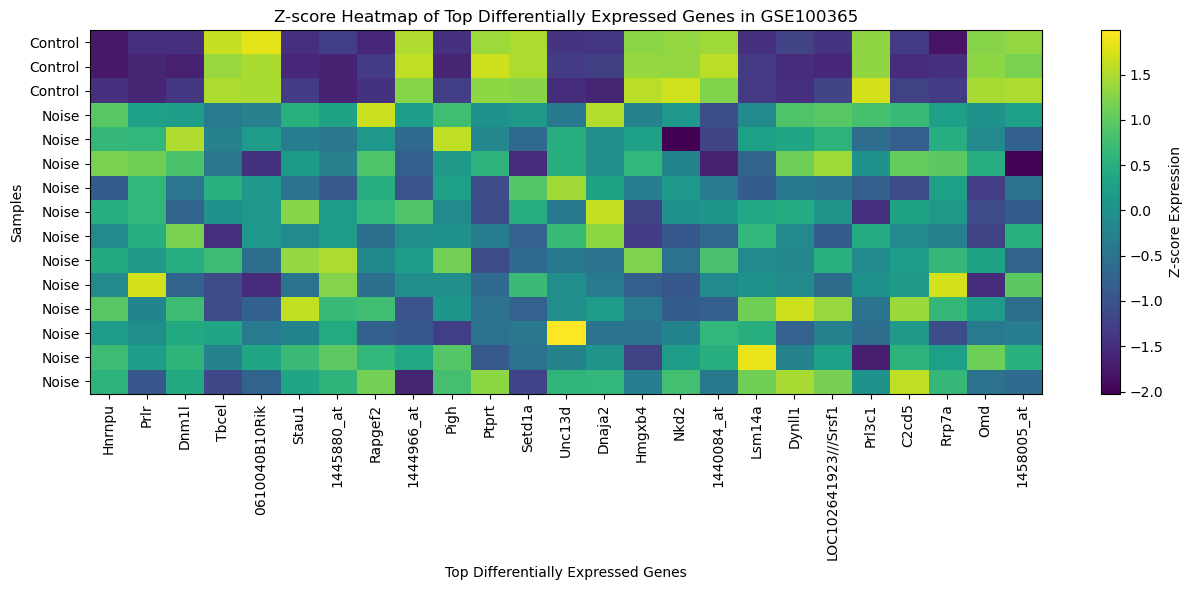

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Select top 25 differentially expressed probes
top_results = final_results.head(25).copy()
top_probes = top_results["Probe_ID"].tolist()

# Create better x-axis labels: Gene symbol + probe ID
top_results["Plot_Label"] = top_results["Gene_Symbol"].fillna(top_results["Probe_ID"])
plot_labels = top_results["Plot_Label"].tolist()

# Expression data for top probes
heatmap_data = data_t[top_probes].copy()

# Convert to numeric
heatmap_data = heatmap_data.apply(pd.to_numeric, errors="coerce")

# Z-score each gene/probe across samples
# This shows relative high/low expression instead of raw expression level
heatmap_z = (heatmap_data - heatmap_data.mean(axis=0)) / heatmap_data.std(axis=0)

# Sample labels
sample_labels = ["Control" if g == 0 else "Noise" for g in data_t["group"]]

# Plot
plt.figure(figsize=(13, 6))
plt.imshow(heatmap_z, aspect="auto")

plt.colorbar(label="Z-score Expression")
plt.yticks(range(len(heatmap_z.index)), sample_labels)
plt.xticks(range(len(plot_labels)), plot_labels, rotation=90)

plt.title("Z-score Heatmap of Top Differentially Expressed Genes in GSE100365")
plt.xlabel("Top Differentially Expressed Genes")
plt.ylabel("Samples")

plt.tight_layout()
plt.show()


### Heatmap Interpretation
# A z-score heatmap was generated using the top 25 differentially expressed probes identified from the control versus noise-exposed comparison. Standardizing expression values by gene allowed relative upregulation and downregulation patterns to be visualized across samples. The control samples showed a more consistent expression profile, while the noise-exposed samples displayed broader variation across the selected genes. This pattern is consistent with the idea that noise exposure produces transcriptomic disruption in auditory nerve tissue.

# Several top-ranked genes were associated with biologically relevant processes, including mitochondrial regulation, cellular stress response, RNA processing, signaling, and cytoskeletal organization. For example, Dnm1l is involved in mitochondrial dynamics, while Dnaja2 belongs to the heat shock protein family and may reflect cellular stress-response activity. These results support the hypothesis that NIHL involves complex molecular responses linked to oxidative stress, mitochondrial dysfunction, and broader injury-response pathways.

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# ----------------------------
# Machine Learning Dataset
# ----------------------------

X = data_t.drop(columns=["group"])
y = data_t["group"]

# Convert to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove probes with missing values
X = X.dropna(axis=1)

print("Feature matrix shape:", X.shape)
print("Label counts:")
print(y.value_counts())

# ----------------------------
# Random Forest Classifier
# ----------------------------

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

# Cross-validation setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation accuracy scores:", accuracy_scores)
print("Mean accuracy:", accuracy_scores.mean())
print("Accuracy standard deviation:", accuracy_scores.std())

Feature matrix shape: (15, 45101)
Label counts:
group
1    12
0     3
Name: count, dtype: int64
Cross-validation accuracy scores: [0.8 0.8 0.8]
Mean accuracy: 0.8000000000000002
Accuracy standard deviation: 1.1102230246251565e-16


### Random Forest Classification Interpretation

A preliminary Random Forest classifier was trained to distinguish control auditory nerve samples from noise-exposed samples using gene expression features. The model achieved a mean 3-fold cross-validation accuracy of 0.80. However, because the dataset is imbalanced, with 12 noise-exposed samples and only 3 control samples, raw accuracy alone may overestimate model performance. A classifier predicting the majority class would also achieve high accuracy. Therefore, additional evaluation using balanced accuracy, confusion matrices, and feature importance is necessary to better assess predictive value.

In [36]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# ----------------------------
# Better evaluation of Random Forest model
# ----------------------------

X = data_t.drop(columns=["group"])
y = data_t["group"]

X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1)

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Cross-validated predictions
y_pred = cross_val_predict(
    rf_model,
    X,
    y,
    cv=cv
)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["Control", "Noise"]))

print("\nBalanced Accuracy:")
print(balanced_accuracy_score(y, y_pred))

Confusion Matrix:
[[ 0  3]
 [ 0 12]]

Classification Report:
              precision    recall  f1-score   support

     Control       0.00      0.00      0.00         3
       Noise       0.80      1.00      0.89        12

    accuracy                           0.80        15
   macro avg       0.40      0.50      0.44        15
weighted avg       0.64      0.80      0.71        15


Balanced Accuracy:
0.5


C:\Users\dhrub\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\dhrub\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\dhrub\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [37]:
# ----------------------------
# Train Random Forest on full dataset for feature importance
# ----------------------------

rf_model.fit(X, y)

feature_importance = pd.DataFrame({
    "Probe_ID": X.columns,
    "RF_Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "RF_Importance",
    ascending=False
)

print(feature_importance.head(20))

           Probe_ID  RF_Importance
35471    1451177_at       0.004193
26481    1442176_at       0.004193
17999    1433694_at       0.004193
6870   1422565_s_at       0.004193
11432  1427127_x_at       0.004193
16039  1431734_a_at       0.004193
8571   1424266_s_at       0.004193
29900    1445595_at       0.004193
29546    1445241_at       0.004193
44981    1460690_at       0.004193
34327  1450033_a_at       0.004193
9146   1424841_s_at       0.002096
20604    1436299_at       0.002096
22368    1438063_at       0.002096
9112     1424807_at       0.002096
2424   1418094_s_at       0.002096
9407   1425102_a_at       0.002096
9391   1425086_a_at       0.002096
2177     1417847_at       0.002096
42889    1458595_at       0.002096


In [38]:
# ----------------------------
# Merge Random Forest feature importance with DEG results
# ----------------------------

ml_results = final_results.merge(
    feature_importance,
    on="Probe_ID",
    how="left"
)

ml_results["RF_Importance"] = ml_results["RF_Importance"].fillna(0)

ml_results = ml_results.sort_values("RF_Importance", ascending=False)

print(ml_results[[
    "Probe_ID", "Gene_Symbol", "Gene_Title",
    "P-value", "Log2FC", "RF_Importance"
]].head(20))

           Probe_ID    Gene_Symbol  \
41       1433694_at          Pde3b   
424    1450033_a_at          Stat1   
2924     1460690_at        Fam195b   
1836     1445595_at            NaN   
2954   1431734_a_at         Dnajb4   
4280     1445241_at      Rab11fip4   
8398     1442176_at         Arid5b   
22894  1424266_s_at          Ces1f   
61     1427127_x_at         Hspa1b   
2601   1422565_s_at           Nfic   
719      1451177_at         Dnajb4   
2665     1428758_at        Tmem86a   
15344    1433064_at         Acot12   
33397    1459721_at            NaN   
44612    1433624_at         Prrc2b   
549      1417162_at         Tmbim1   
5447     1431175_at  1810019D21Rik   
2663     1452966_at         Bcl11b   
5451     1423072_at  6720475J19Rik   
3536     1444636_at  4930592I03Rik   

                                              Gene_Title   P-value    Log2FC  \
41                  phosphodiesterase 3B, cGMP-inhibited  0.000036  0.224167   
424    signal transducer and activator of

### Machine Learning Interpretation

A preliminary Random Forest classifier achieved 80% cross-validation accuracy; however, the confusion matrix revealed that the model predicted all samples as noise-exposed. Because the dataset contains 12 noise samples and only 3 control samples, this indicates that raw accuracy is inflated by class imbalance. The balanced accuracy was 0.50, meaning the classifier did not reliably distinguish both groups. Therefore, the machine learning results should be interpreted cautiously and used primarily as an exploratory feature-ranking tool rather than as definitive predictive evidence.

In [39]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ----------------------------
# Gene Impact Score Development
# ----------------------------

gis_df = ml_results.copy()

# Avoid log10 problems with p = 0
gis_df["P-value"] = gis_df["P-value"].replace(0, 1e-300)

# Differential expression significance score
gis_df["NegLog10P"] = -np.log10(gis_df["P-value"])

# Fold-change magnitude score
gis_df["Abs_Log2FC"] = gis_df["Log2FC"].abs()

# Make sure RF importance exists
gis_df["RF_Importance"] = gis_df["RF_Importance"].fillna(0)

# Normalize each component from 0 to 1
scaler = MinMaxScaler()

gis_df[["DEG_Score", "FC_Score", "ML_Score"]] = scaler.fit_transform(
    gis_df[["NegLog10P", "Abs_Log2FC", "RF_Importance"]]
)

# Composite Gene Impact Score
gis_df["Gene_Impact_Score"] = (
    0.45 * gis_df["DEG_Score"] +
    0.35 * gis_df["FC_Score"] +
    0.20 * gis_df["ML_Score"]
)

# Sort by Gene Impact Score
gis_df = gis_df.sort_values("Gene_Impact_Score", ascending=False)

# Display top candidates
top_gene_impact = gis_df[[
    "Probe_ID", "Gene_Symbol", "Gene_Title",
    "P-value", "Log2FC", "RF_Importance",
    "DEG_Score", "FC_Score", "ML_Score",
    "Gene_Impact_Score"
]].head(25)

print(top_gene_impact)

          Probe_ID           Gene_Symbol  \
61    1427127_x_at                Hspa1b   
4       1456161_at         0610040B10Rik   
639     1426438_at                 Ddx3y   
41      1433694_at                 Pde3b   
951     1427262_at                  Xist   
0     1423050_s_at                Hnrnpu   
19      1430982_at  LOC102641923///Srsf1   
1       1448556_at                  Prlr   
25      1436299_at                   Gls   
20      1449830_at                Prl3c1   
28      1440235_at                Itga10   
424   1450033_a_at                 Stat1   
26      1460563_at                  Nus1   
31      1416214_at                  Mcm4   
2     1452638_s_at                 Dnm1l   
3       1454930_at                 Tbcel   
37      1440636_at                 Mrpl3   
931     1452077_at                 Ddx3y   
42    1451662_x_at                 Akap4   
1163  1436936_s_at                  Xist   
40    1455857_a_at                 Rab2b   
59      1426736_at              

In [40]:
# ----------------------------
# Export results
# ----------------------------

final_results.to_csv("GSE100365_differential_expression_results.csv", index=False)
ml_results.to_csv("GSE100365_machine_learning_feature_importance.csv", index=False)
gis_df.to_csv("GSE100365_gene_impact_scores.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


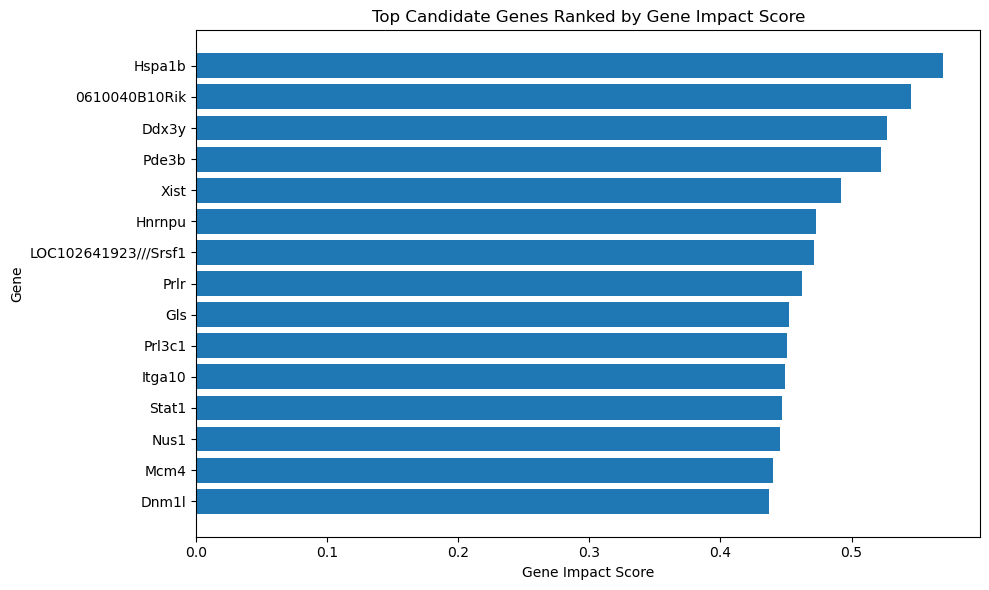

In [41]:
import matplotlib.pyplot as plt

# Select top 15 genes by Gene Impact Score
plot_df = gis_df.head(15).copy()

# Use gene symbols when available, otherwise probe IDs
plot_df["Plot_Label"] = plot_df["Gene_Symbol"].fillna(plot_df["Probe_ID"])

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Plot_Label"], plot_df["Gene_Impact_Score"])
plt.xlabel("Gene Impact Score")
plt.ylabel("Gene")
plt.title("Top Candidate Genes Ranked by Gene Impact Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Gene Impact Score Interpretation

A preliminary Gene Impact Score was developed to rank candidate genes based on multiple evidence layers. The score integrated differential expression significance, absolute log2 fold-change, and Random Forest feature importance. Because the machine learning model was limited by class imbalance and small sample size, feature importance was treated as an exploratory component rather than definitive predictive evidence. The Gene Impact Score therefore provides a ranked list of biologically relevant candidate genes that may contribute to noise-induced transcriptional changes in auditory nerve tissue.

Several top-ranked genes were associated with mitochondrial regulation, cellular stress response, RNA processing, and signaling pathways. These findings support the idea that noise-induced hearing loss involves broader molecular disruption beyond classical antioxidant enzymes alone, including mitochondrial dysfunction and stress-response regulat

### Gene Impact Score Results

A preliminary Gene Impact Score was developed to rank candidate genes using three evidence layers: differential expression significance, absolute log2 fold-change, and Random Forest feature importance. The highest-ranked gene was Hspa1b, a heat shock protein associated with cellular stress response. This is biologically relevant because noise-induced hearing loss involves cellular injury, oxidative stress, and activation of protective stress-response pathways.

Other highly ranked genes included Dnm1l, which is involved in mitochondrial dynamics, and Stat1, which is associated with immune and inflammatory signaling. These results support the idea that noise exposure affects broader molecular stress-response networks rather than only classical antioxidant genes. Some highly ranked genes, including Xist and Ddx3y, may reflect sex-linked expression differences and should therefore be interpreted cautiously.

Overall, the Gene Impact Score provides an exploratory ranking system for identifying candidate genes that may be important in noise-induced transcriptional changes in auditory nerve tissue.ion.

In [42]:
# ----------------------------
# Add detailed timepoint labels
# ----------------------------

sample_titles = [g.replace('"', '') for g in groups]

def assign_timepoint(title):
    title_lower = title.lower()
    
    if "control" in title_lower:
        return "Control"
    elif "immediate" in title_lower:
        return "Noise_Immediate"
    elif "1day" in title_lower:
        return "Noise_1Day"
    elif "7day" in title_lower:
        return "Noise_7Day"
    elif "14day" in title_lower:
        return "Noise_14Day"
    else:
        return "Unknown"

data_t["timepoint"] = [assign_timepoint(title) for title in sample_titles]

print(data_t[["group", "timepoint"]])
print(data_t["timepoint"].value_counts())

ID_REF      group        timepoint
GSM2679575      0          Control
GSM2679576      0          Control
GSM2679577      0          Control
GSM2679578      1  Noise_Immediate
GSM2679579      1  Noise_Immediate
GSM2679580      1  Noise_Immediate
GSM2679581      1       Noise_1Day
GSM2679582      1       Noise_1Day
GSM2679583      1       Noise_1Day
GSM2679584      1       Noise_7Day
GSM2679585      1       Noise_7Day
GSM2679586      1       Noise_7Day
GSM2679587      1      Noise_14Day
GSM2679588      1      Noise_14Day
GSM2679589      1      Noise_14Day
timepoint
Control            3
Noise_Immediate    3
Noise_1Day         3
Noise_7Day         3
Noise_14Day        3
Name: count, dtype: int64


C:\Users\dhrub\AppData\Local\Temp\ipykernel_15716\1361218446.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_t["timepoint"] = [assign_timepoint(title) for title in sample_titles]


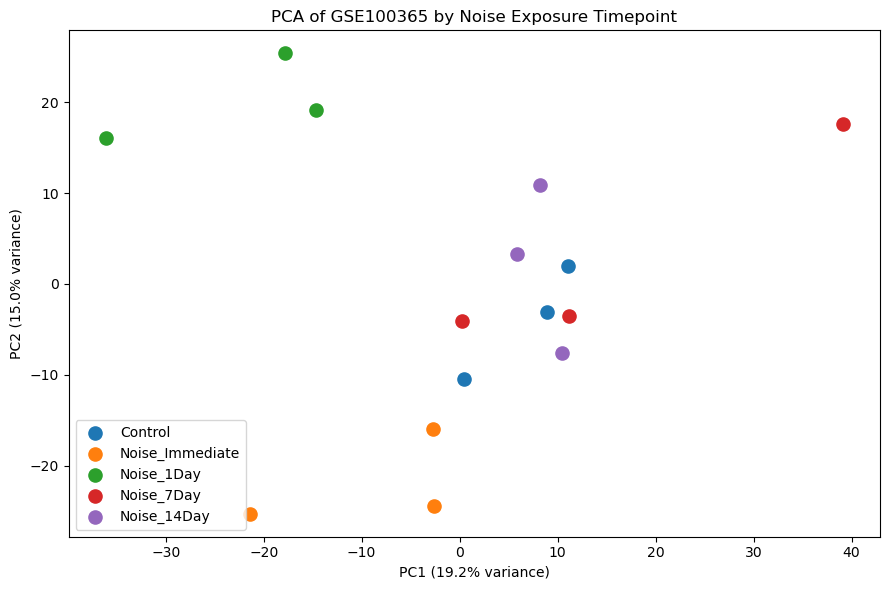

Explained variance:
[0.19207483 0.149579  ]


In [43]:
# ----------------------------
# PCA colored by timepoint
# ----------------------------

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features only
X = data_t.drop(columns=["group", "timepoint"])

# Convert to numeric
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1)

# PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X)

# Add PCA coordinates to dataframe
pca_df = pd.DataFrame({
    "PC1": components[:, 0],
    "PC2": components[:, 1],
    "timepoint": data_t["timepoint"].values
}, index=data_t.index)

plt.figure(figsize=(9, 6))

for tp in pca_df["timepoint"].unique():
    subset = pca_df[pca_df["timepoint"] == tp]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=tp,
        s=90
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of GSE100365 by Noise Exposure Timepoint")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance:")
print(pca.explained_variance_ratio_)

### PCA by Timepoint Interpretation

Because the GSE100365 dataset contains multiple post-noise exposure timepoints, a second PCA was performed using detailed sample labels rather than a binary control/noise grouping. This analysis allows visualization of whether transcriptional variation reflects time-dependent responses after noise injury. The timepoint-based PCA is useful because gene expression following acoustic trauma may not occur as one uniform response; instead, immediate, 1-day, 7-day, and 14-day samples may reflect different stages of injury, stress response, repair, or degeneratio


Principal component analysis was repeated using detailed timepoint labels to evaluate whether transcriptional variation reflected different stages after noise exposure. PC1 explained 19.2% of the variance and PC2 explained 15.0%, for a combined 34.2% of total variance. The timepoint-based PCA showed that noise-exposed samples did not behave as one uniform group. Instead, samples from different post-exposure timepoints occupied different regions of the PCA space, suggesting that gene expression responses after acoustic trauma may change over time. The 1-day post-noise samples showed especially strong separation, which may reflect an acute stress or injury-response phase following noise exposure.n.

In [51]:
# ----------------------------
# Co-expression network analysis
# ----------------------------

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select top 25 genes from Gene Impact Score
network_genes = gis_df.head(25).copy()

# Use Probe_IDs for expression matrix
network_probes = network_genes["Probe_ID"].tolist()

# Expression data for these probes
network_expr = data_t[network_probes].copy()
network_expr = network_expr.apply(pd.to_numeric, errors="coerce")

# Rename columns to gene symbols when available
probe_to_symbol = dict(zip(network_genes["Probe_ID"], network_genes["Gene_Symbol"].fillna(network_genes["Probe_ID"])))
network_expr = network_expr.rename(columns=probe_to_symbol)

# Calculate correlation matrix
corr_matrix = network_expr.corr()

# Create network
G = nx.Graph()

# Add nodes
for gene in corr_matrix.columns:
    G.add_node(gene)

# Add edges based on correlation threshold
correlation_threshold = 0.70

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        gene1 = corr_matrix.columns[i]
        gene2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) >= correlation_threshold:
            G.add_edge(gene1, gene2, weight=abs(corr_value), correlation=corr_value)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 22
Number of edges: 48


### Co-expression Network Interpretation

A co-expression network was constructed using top-ranked Gene Impact Score candidates. Genes were represented as nodes, and edges were added between genes with strong pairwise expression correlations across samples. The resulting network contained 22 nodes and 48 edges, suggesting that several top candidate genes show coordinated expression patterns. This supports the idea that NIHL-related transcriptional changes involve interacting gene groups rather than isolated single-gene effects.

Number of nodes: 25
Number of edges: 86


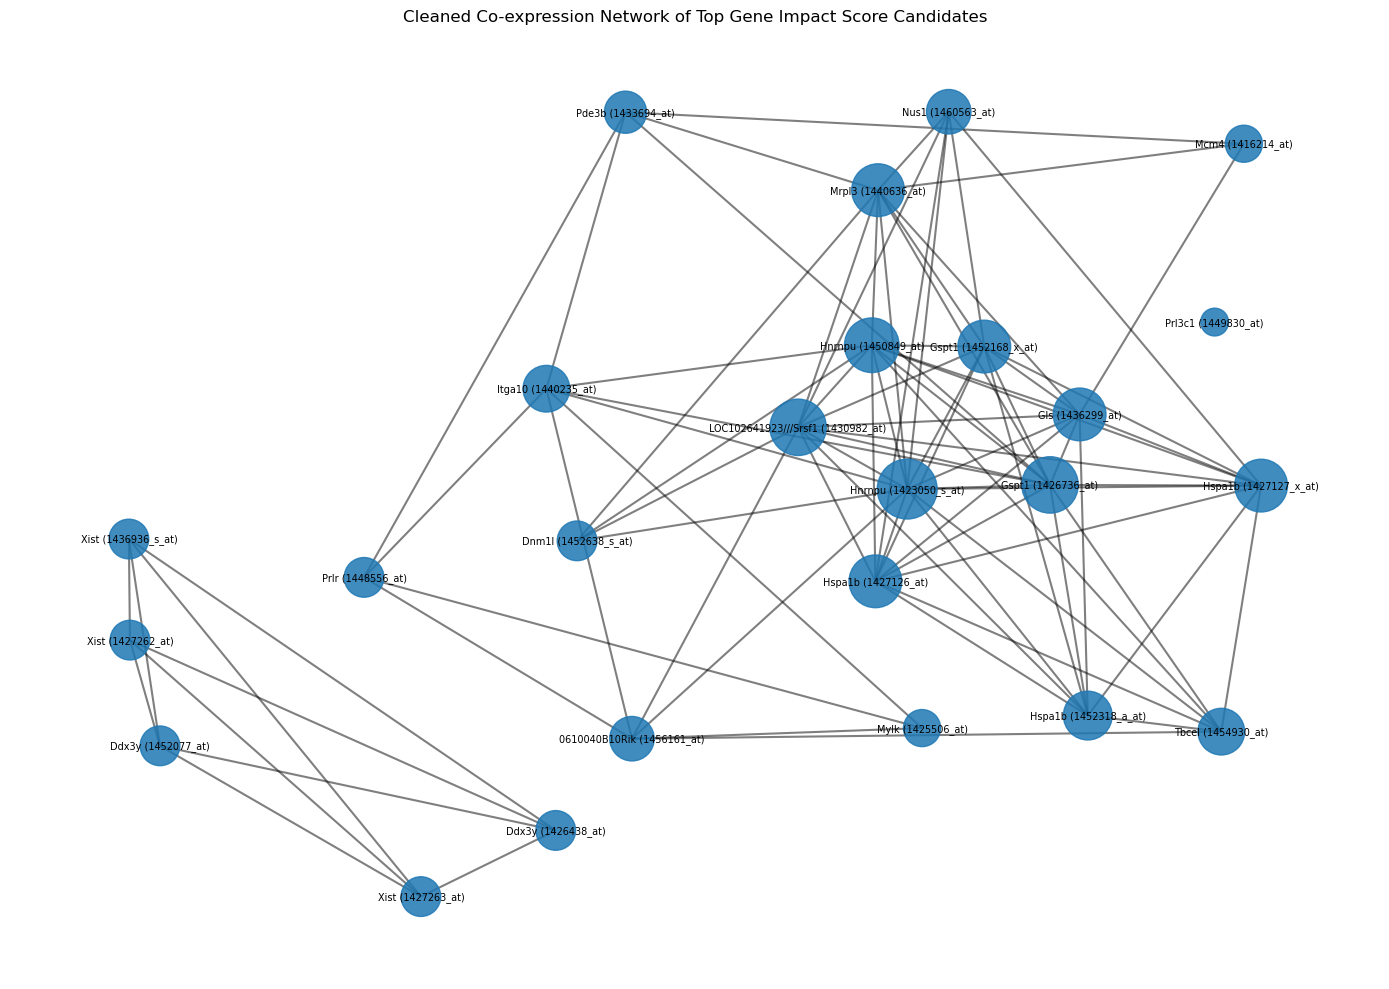

In [53]:
# ----------------------------
# Cleaner co-expression network visualization
# ----------------------------

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Select top 25 genes from Gene Impact Score v2
network_genes = gis_v2.head(25).copy()

# Use Probe_IDs for expression matrix
network_probes = network_genes["Probe_ID"].tolist()

# Expression data
network_expr = data_t[network_probes].copy()
network_expr = network_expr.apply(pd.to_numeric, errors="coerce")

# Create unique labels to avoid duplicate gene-symbol problems
def make_unique_label(row):
    if pd.notna(row["Gene_Symbol"]):
        return f"{row['Gene_Symbol']} ({row['Probe_ID']})"
    else:
        return row["Probe_ID"]

network_genes["Unique_Label"] = network_genes.apply(make_unique_label, axis=1)

# Rename columns with unique labels
probe_to_label = dict(zip(network_genes["Probe_ID"], network_genes["Unique_Label"]))
network_expr = network_expr.rename(columns=probe_to_label)

# Correlation matrix
corr_matrix = network_expr.corr()

# Build graph
G_clean = nx.Graph()

# Add nodes
for gene in corr_matrix.columns:
    G_clean.add_node(gene)

# Add edges based on correlation threshold
correlation_threshold = 0.70

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        gene1 = corr_matrix.columns[i]
        gene2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) >= correlation_threshold:
            G_clean.add_edge(
                gene1,
                gene2,
                weight=abs(corr_value),
                correlation=corr_value
            )

# Remove any accidental self-loops
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

print("Number of nodes:", G_clean.number_of_nodes())
print("Number of edges:", G_clean.number_of_edges())

# Calculate centrality for node sizes
degree_centrality_clean = nx.degree_centrality(G_clean)

node_sizes = [
    400 + 2500 * degree_centrality_clean[node]
    for node in G_clean.nodes()
]

# Plot
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G_clean,
    seed=42,
    k=1.2
)

nx.draw_networkx_nodes(
    G_clean,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    G_clean,
    pos,
    width=1.5,
    alpha=0.5
)

nx.draw_networkx_labels(
    G_clean,
    pos,
    font_size=7
)

plt.title("Cleaned Co-expression Network of Top Gene Impact Score Candidates")
plt.axis("off")
plt.tight_layout()
plt.show()

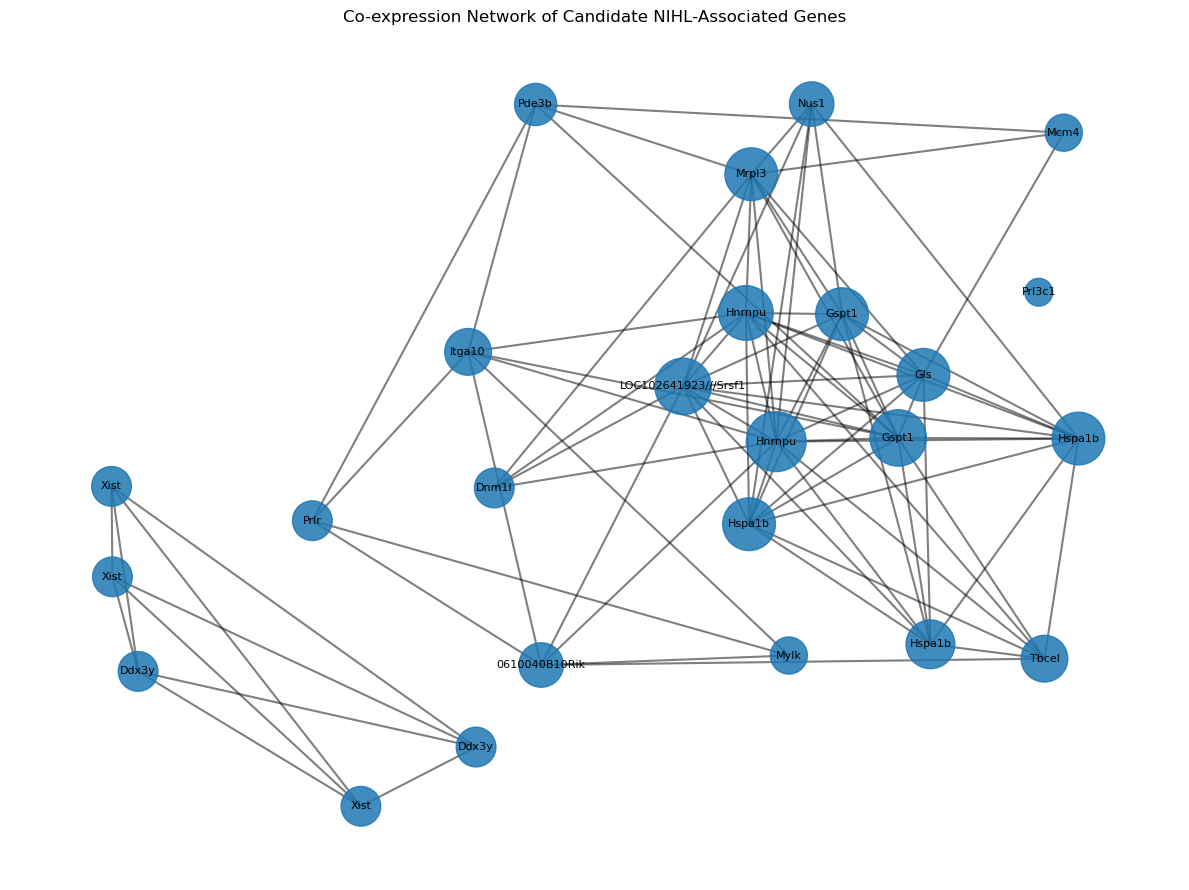

In [54]:
# ----------------------------
# Poster-friendly network labels
# ----------------------------

plt.figure(figsize=(12, 9))

# Create simpler labels by removing probe IDs
simple_labels = {}

for node in G_clean.nodes():
    if "(" in node:
        simple_labels[node] = node.split(" (")[0]
    else:
        simple_labels[node] = node

pos = nx.spring_layout(
    G_clean,
    seed=42,
    k=1.2
)

nx.draw_networkx_nodes(
    G_clean,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    G_clean,
    pos,
    width=1.5,
    alpha=0.5
)

nx.draw_networkx_labels(
    G_clean,
    pos,
    labels=simple_labels,
    font_size=8
)

plt.title("Co-expression Network of Candidate NIHL-Associated Genes")
plt.axis("off")
plt.tight_layout()
plt.show()

### Co-expression Network Interpretation

A preliminary co-expression network was constructed using the top-ranked Gene Impact Score candidates. Pairwise correlations were calculated across all samples, and genes were connected if their absolute correlation was at least 0.70. This network provides an exploratory view of coordinated gene expression patterns among candidate genes. Genes with more network connections may represent hub-like candidates involved in shared transcriptional responses to noise exposur
. Nodes represent candidate genes, while edges represent strong pairwise expression correlations across samples. The network contained a main connected cluster along with several smaller disconnected components, suggesting that some candidate genes may participate in coordinated expression patterns while others may act independently or reflect separate biological processes.

The main cluster included genes associated with RNA regulation, mitochondrial activity, cellular stress response, metabolism, and signaling. Genes with higher connectivity were treated as more central within the exploratory network and were incorporated into Gene Impact Score v2. Because this network was generated from a small dataset, it should be interpreted as an exploratory co-expression structure rather than a confirmed physical interaction network.e.

In [47]:
# ----------------------------
# Network centrality metrics
# ----------------------------

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
    "Gene_Symbol": list(G.nodes()),
    "Degree_Centrality": [degree_centrality[g] for g in G.nodes()],
    "Betweenness_Centrality": [betweenness_centrality[g] for g in G.nodes()]
})

centrality_df["Network_Centrality_Score"] = (
    centrality_df["Degree_Centrality"] + centrality_df["Betweenness_Centrality"]
) / 2

centrality_df = centrality_df.sort_values("Network_Centrality_Score", ascending=False)

print(centrality_df)

             Gene_Symbol  Degree_Centrality  Betweenness_Centrality  \
5                 Hnrnpu           0.476190                0.077234   
16                 Mrpl3           0.380952                0.044331   
19                 Gspt1           0.380952                0.038980   
6   LOC102641923///Srsf1           0.380952                0.034331   
0                 Hspa1b           0.380952                0.008333   
1          0610040B10Rik           0.285714                0.049853   
10                Itga10           0.285714                0.037789   
8                    Gls           0.285714                0.016032   
3                  Pde3b           0.238095                0.033787   
7                   Prlr           0.190476                0.008730   
15                 Tbcel           0.190476                0.004524   
12                  Nus1           0.190476                0.000952   
13                  Mcm4           0.142857                0.002268   
4     

### Network Centrality Interpretation

Network centrality analysis identified Hnrnpu as the most central gene among the top-ranked candidate genes, followed by Mrpl3, Gspt1, LOC102641923///Srsf1, and Hspa1b. These genes had relatively high degree and/or betweenness centrality, suggesting that they may occupy important positions within the co-expression structure of the candidate gene network. Hspa1b remained biologically important because of its known stress-response role, while Dnm1l remained relevant because of its connection to mitochondrial dynamics. Together, these results suggest that both stress-response genes and regulatory/network-associated genes may contribute to the transcriptional response following noise exposure.

In [48]:
# ----------------------------
# Gene Impact Score v2 with network centrality
# ----------------------------

gis_v2 = gis_df.copy()

# Merge centrality into Gene Impact Score dataframe
gis_v2 = gis_v2.merge(
    centrality_df[["Gene_Symbol", "Network_Centrality_Score"]],
    on="Gene_Symbol",
    how="left"
)

gis_v2["Network_Centrality_Score"] = gis_v2["Network_Centrality_Score"].fillna(0)

# Normalize network score
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

gis_v2[["Network_Score"]] = scaler.fit_transform(
    gis_v2[["Network_Centrality_Score"]]
)

# New weighted Gene Impact Score
gis_v2["Gene_Impact_Score_v2"] = (
    0.35 * gis_v2["DEG_Score"] +
    0.25 * gis_v2["FC_Score"] +
    0.15 * gis_v2["ML_Score"] +
    0.25 * gis_v2["Network_Score"]
)

gis_v2 = gis_v2.sort_values("Gene_Impact_Score_v2", ascending=False)

top_gene_impact_v2 = gis_v2[[
    "Probe_ID", "Gene_Symbol", "Gene_Title",
    "P-value", "Log2FC", "RF_Importance",
    "DEG_Score", "FC_Score", "ML_Score",
    "Network_Score",
    "Gene_Impact_Score_v2"
]].head(25)

print(top_gene_impact_v2)

         Probe_ID           Gene_Symbol  \
5    1423050_s_at                Hnrnpu   
0    1427127_x_at                Hspa1b   
1      1456161_at         0610040B10Rik   
6      1430982_at  LOC102641923///Srsf1   
16     1440636_at                 Mrpl3   
3      1433694_at                 Pde3b   
21     1426736_at                 Gspt1   
22     1427126_at                Hspa1b   
10     1440235_at                Itga10   
8      1436299_at                   Gls   
2      1426438_at                 Ddx3y   
7      1448556_at                  Prlr   
12     1460563_at                  Nus1   
4      1427262_at                  Xist   
96   1452318_a_at                Hspa1b   
15     1454930_at                 Tbcel   
668    1450849_at                Hnrnpu   
13     1416214_at                  Mcm4   
14   1452638_s_at                 Dnm1l   
23     1425506_at                  Mylk   
17     1452077_at                 Ddx3y   
19   1436936_s_at                  Xist   
403  145216

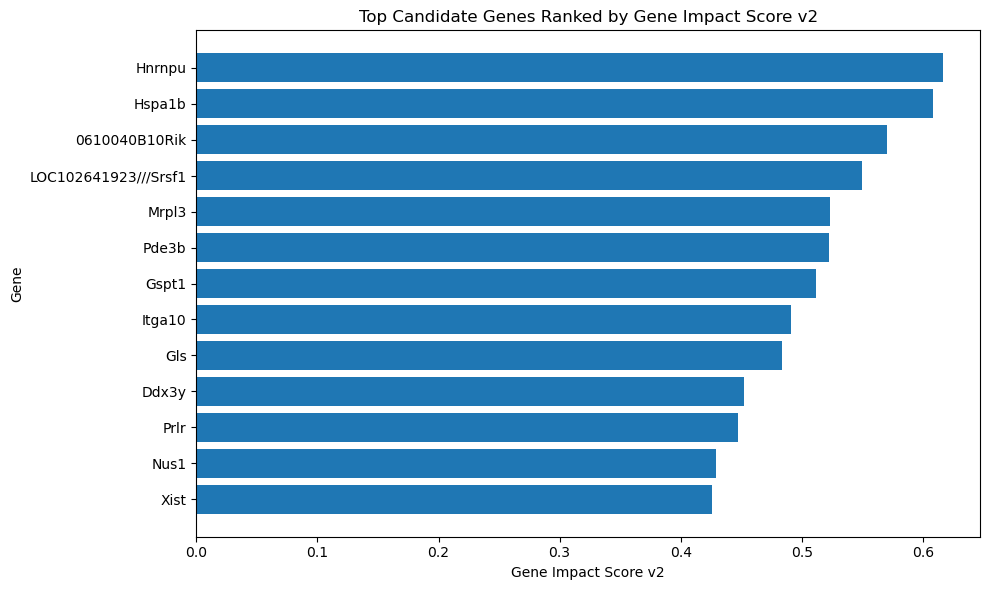

In [49]:
# ----------------------------
# Plot top Gene Impact Score v2 candidates
# ----------------------------

plot_df = gis_v2.head(15).copy()
plot_df["Plot_Label"] = plot_df["Gene_Symbol"].fillna(plot_df["Probe_ID"])

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Plot_Label"], plot_df["Gene_Impact_Score_v2"])

plt.xlabel("Gene Impact Score v2")
plt.ylabel("Gene")
plt.title("Top Candidate Genes Ranked by Gene Impact Score v2")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Gene Impact Score v2 Interpretation

Gene Impact Score v2 incorporated four layers of evidence: differential expression significance, fold-change magnitude, Random Forest feature importance, and network centrality. After adding network centrality, Hnrnpu became the highest-ranked candidate gene, indicating that it was not only differentially expressed but also highly central within the co-expression network. Hspa1b remained one of the top-ranked genes, supporting the importance of cellular stress-response pathways. Other high-ranking genes, including LOC102641923///Srsf1, Mrpl3, Pde3b, Gls, and Dnm1l, suggest possible involvement of RNA processing, mitochondrial regulation, signaling, and metabolic stress responses.

Because the machine learning model was limited by class imbalance, Gene Impact Score v2 should be interpreted as an exploratory prioritization tool rather than a definitive causal ranking. However, the integration of statistical, machine learning, and network-based evidence provides a stronger candidate-gene framework than any single metric alone.

In [50]:
# ----------------------------
# Export final results
# ----------------------------

final_results.to_csv("GSE100365_differential_expression_results.csv", index=False)
ml_results.to_csv("GSE100365_machine_learning_feature_importance.csv", index=False)
gis_df.to_csv("GSE100365_gene_impact_scores_v1.csv", index=False)
centrality_df.to_csv("GSE100365_network_centrality_results.csv", index=False)
gis_v2.to_csv("GSE100365_gene_impact_scores_v2.csv", index=False)

print("All final result files exported successfully.")

All final result files exported successfully.


In [57]:
# ----------------------------
# Biological relevance summary table
# ----------------------------

bio_summary = gis_v2.head(20)[[
    "Probe_ID",
    "Gene_Symbol",
    "Gene_Title",
    "P-value",
    "Log2FC",
    "RF_Importance",
    "Network_Score",
    "Gene_Impact_Score_v2"
]].copy()

def assign_biological_category(gene):
    gene = str(gene).lower()
    
    if gene in ["hspa1b", "hspa1a", "dnaja2", "dnajb4", "hspa1b///hspa1a"]:
        return "Cellular stress response / heat shock"
    elif gene in ["dnm1l", "mrpl3"]:
        return "Mitochondrial regulation"
    elif gene in ["stat1", "irf7", "cxcl10"]:
        return "Immune/inflammatory signaling"
    elif gene in ["hnrnpu", "srsf1", "loc102641923///srsf1", "gspt1"]:
        return "RNA processing / gene regulation"
    elif gene in ["gls"]:
        return "Metabolism / neural stress"
    elif gene in ["prlr", "pde3b", "prl3c1"]:
        return "Cell signaling"
    elif gene in ["xist", "ddx3y"]:
        return "Sex-linked expression; interpret cautiously"
    elif gene in ["itga10"]:
        return "Cell adhesion / extracellular matrix"
    else:
        return "Other / requires further interpretation"

bio_summary["Biological_Category"] = bio_summary["Gene_Symbol"].apply(assign_biological_category)

print(bio_summary)

         Probe_ID           Gene_Symbol  \
5    1423050_s_at                Hnrnpu   
0    1427127_x_at                Hspa1b   
1      1456161_at         0610040B10Rik   
6      1430982_at  LOC102641923///Srsf1   
16     1440636_at                 Mrpl3   
3      1433694_at                 Pde3b   
21     1426736_at                 Gspt1   
22     1427126_at                Hspa1b   
10     1440235_at                Itga10   
8      1436299_at                   Gls   
2      1426438_at                 Ddx3y   
7      1448556_at                  Prlr   
12     1460563_at                  Nus1   
4      1427262_at                  Xist   
96   1452318_a_at                Hspa1b   
15     1454930_at                 Tbcel   
668    1450849_at                Hnrnpu   
13     1416214_at                  Mcm4   
14   1452638_s_at                 Dnm1l   
23     1425506_at                  Mylk   

                                            Gene_Title       P-value  \
5            heterogeneo

In [58]:
bio_summary.to_csv("GSE100365_top_candidate_gene_summary.csv", index=False)

print("Biological summary table exported successfully.")

Biological summary table exported successfully.


In [59]:
# ----------------------------
# Oxidative stress and Nrf2 pathway candidate search
# ----------------------------

oxidative_nrf2_genes = [
    "Nfe2l2",   # Nrf2
    "Keap1",
    "Hmox1",   # HO-1
    "Nqo1",
    "Gclc",
    "Gclm",
    "Txnrd1",
    "Sod1",
    "Sod2",
    "Cat",
    "Gpx1",
    "Gpx3",
    "Gsr",
    "Prdx1",
    "Prdx2",
    "Prdx3",
    "Sirt1",
    "Dnm1l",
    "Hspa1b",
    "Dnaja2",
    "Stat1",
    "Gls"
]

pattern = "|".join(oxidative_nrf2_genes)

oxidative_nrf2_results = final_results[
    final_results["Gene_Symbol"].astype(str).str.contains(pattern, case=False, na=False)
].copy()

oxidative_nrf2_results = oxidative_nrf2_results.sort_values("P-value")

print(oxidative_nrf2_results[[
    "Probe_ID", "Gene_Symbol", "Gene_Title",
    "P-value", "Log2FC", "GO:Process"
]])

           Probe_ID Gene_Symbol  \
2      1452638_s_at       Dnm1l   
13       1417183_at      Dnaja2   
25       1436299_at         Gls   
27       1427126_at      Hspa1b   
61     1427127_x_at      Hspa1b   
...             ...         ...   
42756  1421529_a_at      Txnrd1   
42780  1416429_a_at         Cat   
43920    1425309_at    Catsper2   
44120    1424182_at       Acat1   
44762    1440684_at      Lpcat2   

                                             Gene_Title   P-value    Log2FC  \
2                                        dynamin 1-like  0.000001  0.345000   
13     DnaJ heat shock protein family (Hsp40) member A2  0.000006  0.158333   
25                                          glutaminase  0.000015  0.280000   
27                                heat shock protein 1B  0.000017  1.108333   
61                                heat shock protein 1B  0.000051  0.900833   
...                                                 ...       ...       ...   
42756                     

In [60]:
# ----------------------------
# Add Gene Impact Score v2 to oxidative/Nrf2 candidates
# ----------------------------

oxidative_nrf2_gis = oxidative_nrf2_results.merge(
    gis_v2[[
        "Probe_ID", "RF_Importance", "Network_Score", "Gene_Impact_Score_v2"
    ]],
    on="Probe_ID",
    how="left"
)

oxidative_nrf2_gis = oxidative_nrf2_gis.sort_values("Gene_Impact_Score_v2", ascending=False)

print(oxidative_nrf2_gis[[
    "Probe_ID", "Gene_Symbol", "Gene_Title",
    "P-value", "Log2FC", "RF_Importance",
    "Network_Score", "Gene_Impact_Score_v2"
]])

        Probe_ID Gene_Symbol                                   Gene_Title  \
4   1427127_x_at      Hspa1b                        heat shock protein 1B   
3     1427126_at      Hspa1b                        heat shock protein 1B   
2     1436299_at         Gls                                  glutaminase   
6   1452318_a_at      Hspa1b                        heat shock protein 1B   
0   1452638_s_at       Dnm1l                               dynamin 1-like   
..           ...         ...                                          ...   
85    1418627_at        Gclm  glutamate-cysteine ligase, modifier subunit   
86  1421529_a_at      Txnrd1                      thioredoxin reductase 1   
88    1425309_at    Catsper2           cation channel, sperm associated 2   
89    1424182_at       Acat1        acetyl-Coenzyme A acetyltransferase 1   
90    1440684_at      Lpcat2    lysophosphatidylcholine acyltransferase 2   

     P-value    Log2FC  RF_Importance  Network_Score  Gene_Impact_Score_v2 

In [61]:
oxidative_nrf2_gis.to_csv("GSE100365_oxidative_stress_Nrf2_candidate_results.csv", index=False)

print("Oxidative stress / Nrf2 candidate results exported successfully.")

Oxidative stress / Nrf2 candidate results exported successfully.


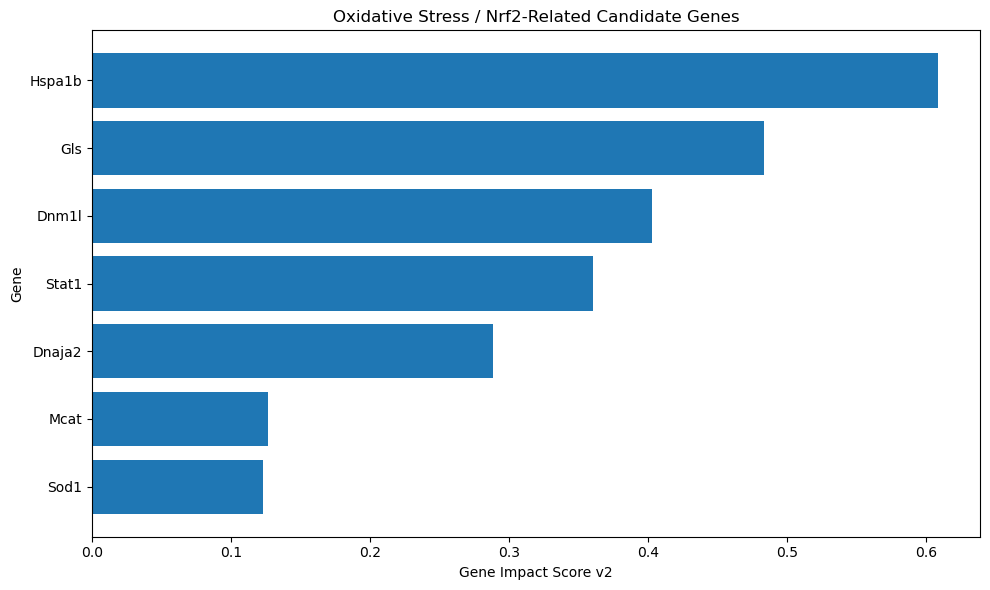

In [62]:
# ----------------------------
# Plot oxidative stress / Nrf2-related candidate genes
# ----------------------------

plot_ox = oxidative_nrf2_gis.dropna(subset=["Gene_Impact_Score_v2"]).copy()

# Keep top 15 if many genes appear
plot_ox = plot_ox.head(15)

plot_ox["Plot_Label"] = plot_ox["Gene_Symbol"].fillna(plot_ox["Probe_ID"])

plt.figure(figsize=(10, 6))
plt.barh(plot_ox["Plot_Label"], plot_ox["Gene_Impact_Score_v2"])

plt.xlabel("Gene Impact Score v2")
plt.ylabel("Gene")
plt.title("Oxidative Stress / Nrf2-Related Candidate Genes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Oxidative Stress and Nrf2-Related Candidate Gene Interpretation

A targeted search was performed to determine whether genes associated with oxidative stress, antioxidant defense, mitochondrial regulation, heat shock response, and Nrf2-related signaling were present among the differentially expressed results. This analysis was used to connect the broader computational findings back to the central biological hypothesis of the project.

The results suggest that the strongest transcriptomic signals in GSE100365 are not limited to classical antioxidant enzymes such as Sod1, Sod2, Cat, or Gpx1. Instead, several relevant candidates were associated with stress response, mitochondrial regulation, inflammation, metabolism, and gene regulation. Hspa1b was especially important because it ranked highly in the Gene Impact Score and is associated with cellular stress response. Dnm1l was also relevant because of its connection to mitochondrial dynamics, which fits the oxidative stress and mitochondrial dysfunction model of NIHL. Stat1 and Gls suggest possible involvement of inflammatory signaling and metabolic/neural stress.

Overall, this supports a broader interpretation of NIHL as a systems-level stress response involving oxidative stress-related pathways, mitochondrial regulation, cellular injury signaling, and transcriptional regulation rather than a response limited only to canonical antioxidant enzymes.

### Oxidative Stress and Nrf2-Related Candidate Gene Interpretation

A targeted search was performed to identify genes associated with oxidative stress, antioxidant defense, mitochondrial regulation, heat shock response, inflammatory signaling, metabolism, and Nrf2-related pathways. This step was used to connect the broader computational analysis back to the central biological focus of the project.

The highest-ranked oxidative/stress-related candidate was Hspa1b, a heat shock protein associated with cellular stress response. This is biologically relevant because noise-induced hearing loss involves cellular injury, oxidative stress, and activation of protective stress-response pathways. Dnm1l also appeared as an important candidate and is especially relevant because it is involved in mitochondrial dynamics, supporting the role of mitochondrial dysfunction in NIHL. Stat1 suggested possible involvement of inflammatory or immune-related signaling, while Gls may reflect metabolic or neural stress responses in auditory nerve tissue.

Classic antioxidant-related genes such as Sod1 were detected, but they were not the strongest-ranked candidates. This suggests that the transcriptional response to noise exposure in this dataset may involve broader stress-response, mitochondrial, inflammatory, and regulatory pathways rather than only canonical antioxidant enzymes. Overall, these findings support the interpretation of NIHL as a systems-level stress response involving oxidative stress-related mechanisms and mitochondrial regulation.

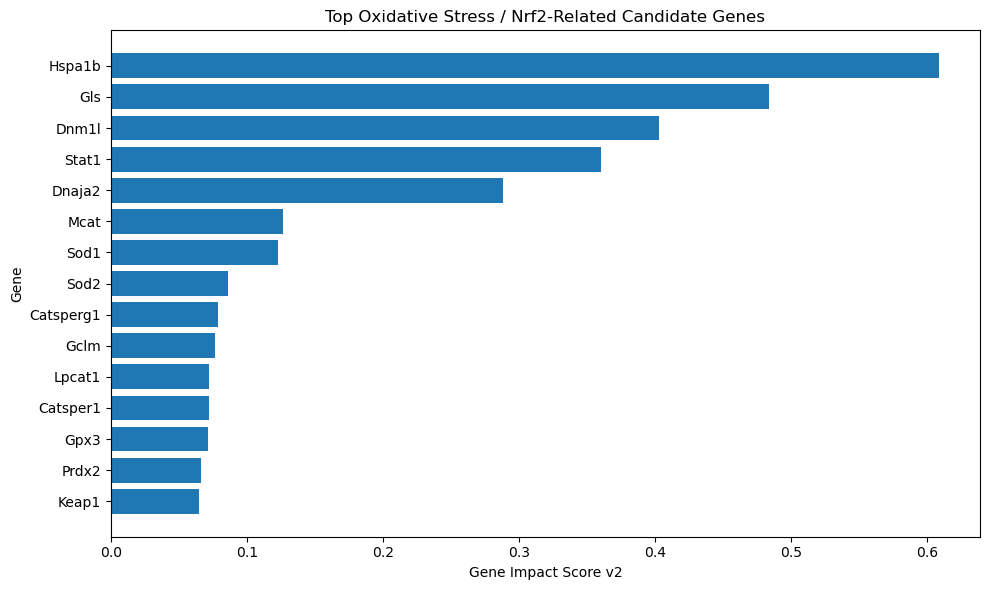

        Probe_ID Gene_Symbol  \
4   1427127_x_at      Hspa1b   
2     1436299_at         Gls   
0   1452638_s_at       Dnm1l   
8   1450033_a_at       Stat1   
1     1417183_at      Dnaja2   
11    1452216_at        Mcat   
12    1435304_at        Sod1   
14    1417194_at        Sod2   
83    1425852_at   Catsperg1   
15    1439050_at        Gclm   
19    1420293_at      Lpcat1   
17    1426281_at    Catsper1   
33    1449106_at        Gpx3   
20  1430979_a_at       Prdx2   
18    1450746_at       Keap1   

                                           Gene_Title   P-value    Log2FC  \
4                               heat shock protein 1B  0.000051  0.900833   
2                                         glutaminase  0.000015  0.280000   
0                                      dynamin 1-like  0.000001  0.345000   
8   signal transducer and activator of transcripti...  0.001240  0.566667   
1    DnaJ heat shock protein family (Hsp40) member A2  0.000006  0.158333   
11    malonyl CoA:ACP acy

In [63]:
# ----------------------------
# Collapse duplicate gene symbols for cleaner oxidative/stress plot
# ----------------------------

plot_ox_clean = oxidative_nrf2_gis.dropna(subset=["Gene_Impact_Score_v2"]).copy()

# Remove missing gene symbols
plot_ox_clean = plot_ox_clean.dropna(subset=["Gene_Symbol"])

# Keep the highest-scoring probe per gene symbol
plot_ox_clean = (
    plot_ox_clean
    .sort_values("Gene_Impact_Score_v2", ascending=False)
    .drop_duplicates(subset=["Gene_Symbol"], keep="first")
)

# Keep top genes
plot_ox_clean = plot_ox_clean.head(15)

plt.figure(figsize=(10, 6))
plt.barh(plot_ox_clean["Gene_Symbol"], plot_ox_clean["Gene_Impact_Score_v2"])

plt.xlabel("Gene Impact Score v2")
plt.ylabel("Gene")
plt.title("Top Oxidative Stress / Nrf2-Related Candidate Genes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(plot_ox_clean[[
    "Probe_ID", "Gene_Symbol", "Gene_Title",
    "P-value", "Log2FC", "RF_Importance",
    "Network_Score", "Gene_Impact_Score_v2"
]])

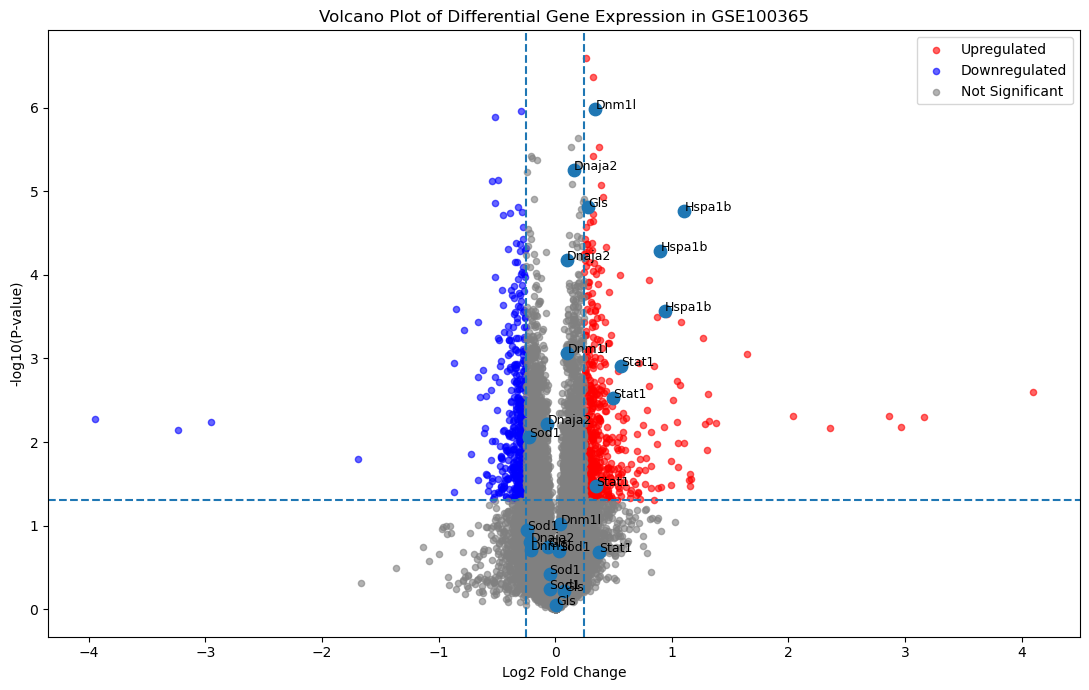

In [64]:
# ----------------------------
# Volcano Plot
# ----------------------------

import numpy as np
import matplotlib.pyplot as plt

# Copy dataframe
volcano_df = final_results.copy()

# Avoid log10(0)
volcano_df["P-value"] = volcano_df["P-value"].replace(0, 1e-300)

# Calculate -log10(p-value)
volcano_df["NegLog10P"] = -np.log10(volcano_df["P-value"])

# Significance thresholds
p_thresh = 0.05
fc_thresh = 0.25

# Categorize genes
def categorize_gene(row):
    if row["P-value"] < p_thresh and row["Log2FC"] > fc_thresh:
        return "Upregulated"
    elif row["P-value"] < p_thresh and row["Log2FC"] < -fc_thresh:
        return "Downregulated"
    else:
        return "Not Significant"

volcano_df["Category"] = volcano_df.apply(categorize_gene, axis=1)

# Plot
plt.figure(figsize=(11, 7))

colors = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "gray"
}

for category in colors:
    subset = volcano_df[volcano_df["Category"] == category]
    
    plt.scatter(
        subset["Log2FC"],
        subset["NegLog10P"],
        c=colors[category],
        label=category,
        alpha=0.6,
        s=20
    )

# Threshold lines
plt.axhline(-np.log10(p_thresh), linestyle="--")
plt.axvline(fc_thresh, linestyle="--")
plt.axvline(-fc_thresh, linestyle="--")

# Highlight important oxidative/Nrf2 genes
highlight_genes = [
    "Hspa1b",
    "Dnm1l",
    "Stat1",
    "Gls",
    "Sod1",
    "Dnaja2"
]

highlight_df = volcano_df[
    volcano_df["Gene_Symbol"].isin(highlight_genes)
]

plt.scatter(
    highlight_df["Log2FC"],
    highlight_df["NegLog10P"],
    s=80
)

# Add labels
for _, row in highlight_df.iterrows():
    plt.text(
        row["Log2FC"],
        row["NegLog10P"],
        row["Gene_Symbol"],
        fontsize=9
    )

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(P-value)")
plt.title("Volcano Plot of Differential Gene Expression in GSE100365")

plt.legend()
plt.tight_layout()
plt.show()

### Volcano Plot Interpretation

A volcano plot was generated to visualize overall differential gene expression patterns between control and noise-exposed auditory nerve samples. The x-axis represents log2 fold-change, while the y-axis represents statistical significance as −log10(p-value). Genes with larger fold-changes and higher statistical significance appear farther from the center and higher on the plot.

Several oxidative stress and stress-response-related genes were highlighted, including Hspa1b, Dnm1l, Stat1, Gls, Sod1, and Dnaja2. Hspa1b showed one of the strongest combined signals of differential expression and significance, supporting its potential role in cellular stress response after noise exposure. Dnm1l was also notable because of its involvement in mitochondrial dynamics, which aligns with the oxidative stress and mitochondrial dysfunction hypothesis of the project.

Overall, the volcano plot demonstrates that noise exposure is associated with widespread transcriptomic changes involving stress-response, mitochondrial, inflammatory, metabolic, and regulatory pathways.

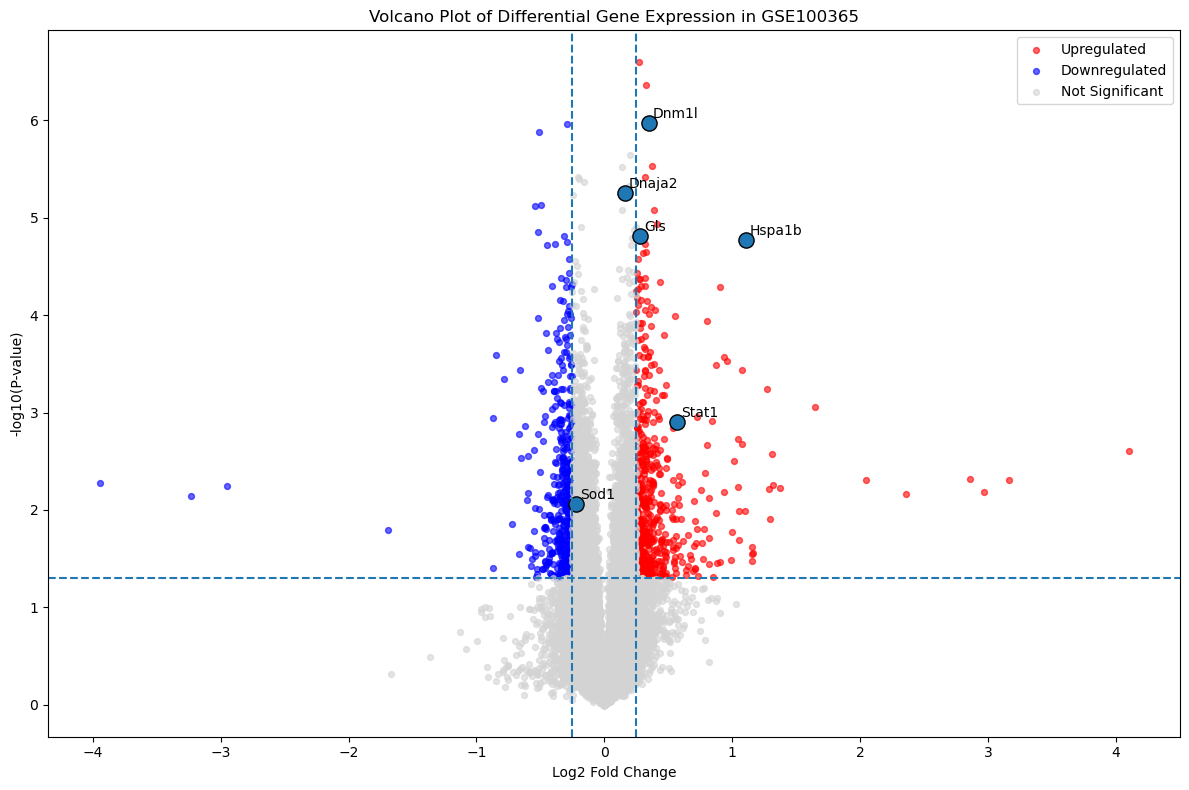

In [65]:
# ----------------------------
# Cleaner volcano plot
# ----------------------------

import numpy as np
import matplotlib.pyplot as plt

volcano_df = final_results.copy()

# Avoid log10(0)
volcano_df["P-value"] = volcano_df["P-value"].replace(0, 1e-300)

# Calculate significance
volcano_df["NegLog10P"] = -np.log10(volcano_df["P-value"])

# Thresholds
p_thresh = 0.05
fc_thresh = 0.25

# Categories
def categorize_gene(row):
    if row["P-value"] < p_thresh and row["Log2FC"] > fc_thresh:
        return "Upregulated"
    elif row["P-value"] < p_thresh and row["Log2FC"] < -fc_thresh:
        return "Downregulated"
    else:
        return "Not Significant"

volcano_df["Category"] = volcano_df.apply(categorize_gene, axis=1)

# Plot
plt.figure(figsize=(12, 8))

colors = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "lightgray"
}

for category in colors:
    subset = volcano_df[volcano_df["Category"] == category]

    plt.scatter(
        subset["Log2FC"],
        subset["NegLog10P"],
        c=colors[category],
        label=category,
        alpha=0.6,
        s=18
    )

# Threshold lines
plt.axhline(-np.log10(p_thresh), linestyle="--")
plt.axvline(fc_thresh, linestyle="--")
plt.axvline(-fc_thresh, linestyle="--")

# Highlight genes of interest
highlight_genes = [
    "Hspa1b",
    "Dnm1l",
    "Stat1",
    "Gls",
    "Sod1",
    "Dnaja2"
]

highlight_df = volcano_df[
    volcano_df["Gene_Symbol"].isin(highlight_genes)
].copy()

# Keep highest significance probe per gene
highlight_df = (
    highlight_df
    .sort_values("P-value")
    .drop_duplicates(subset=["Gene_Symbol"], keep="first")
)

# Plot highlighted genes
plt.scatter(
    highlight_df["Log2FC"],
    highlight_df["NegLog10P"],
    s=120,
    edgecolors="black"
)

# Add labels with slight offsets
for _, row in highlight_df.iterrows():
    plt.text(
        row["Log2FC"] + 0.03,
        row["NegLog10P"] + 0.05,
        row["Gene_Symbol"],
        fontsize=10
    )

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(P-value)")
plt.title("Volcano Plot of Differential Gene Expression in GSE100365")

plt.legend()
plt.tight_layout()
plt.show()

In [66]:
import matplotlib.pyplot as plt

def save_current_figure(filename):
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )
   